# Customer Churn Prediction Using an End-to-End Scikit-learn Pipeline

## Problem Statement

Customer churn is one of the biggest challenges faced by telecommunication companies. Retaining existing customers is often more cost-effective than acquiring new ones. Therefore, accurately predicting which customers are likely to leave the service can help organizations take proactive retention measures.

## Objective

The objective of this project is to build a reusable and production-ready machine learning pipeline for customer churn prediction using the Telco Customer Churn dataset. The project includes data preprocessing, model training, hyperparameter tuning, evaluation, and exporting the final pipeline for future use.

## Project Workflow

The project follows the following workflow:

1. Import required libraries
2. Load and inspect the dataset
3. Perform exploratory data analysis (EDA)
4. Preprocess the data
5. Build preprocessing pipelines using Scikit-learn
6. Train Logistic Regression and Random Forest models
7. Optimize models using GridSearchCV
8. Evaluate model performance
9. Export the complete pipeline using Joblib
10. Summarize key findings

# 1. Import Required Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load the Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame. This initial step allows us to inspect the dataset's structure, verify that it has been loaded correctly, and gain a preliminary understanding of the available features before performing any preprocessing or analysis.

In [2]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Dataset Overview

This includes examining the number of rows and columns, identifying data types, and checking for missing values.

In [3]:
# Display the dimensions of the dataset
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

# 4. Missing Values and Duplicate Records

Missing values and duplicate records can negatively impact model performance and lead to biased results.So, we check whether the dataset contains any null values or duplicate observations that need to be handled before model development.

In [4]:
print("total null values in each cols:\n",df.isnull().sum())
print("total duplicate records:\n",df.duplicated().sum())

total null values in each cols:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
total duplicate records:
 0


# 5. Statistical Summary and Data Types

Understanding the statistical properties and data types of the dataset helps identify the nature of each feature and detect potential data quality issues. This step provides descriptive statistics for numerical variables and summarizes the categorical features before proceeding with preprocessing.

In [5]:
print("statistical summary of numerical data")
display(df.describe())
print("statistical summary of catgorical data")
display(df.describe(include="object"))


statistical summary of numerical data


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


statistical summary of catgorical data


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# 6. Handling the `TotalCharges` Data Type

Although the dataset does not contain any explicit missing (`NaN`) values, the `TotalCharges` feature is stored as an object instead of a numeric data type. This usually occurs because some records contain blank spaces rather than valid numeric values.

In this step, we:
- Identify blank string values in the `TotalCharges` column.
- Convert the column to a numeric data type.
- Replace invalid values with `NaN`.
- Impute the missing values using the median.
- Verify that the column has been successfully converted to a numeric format.

This preprocessing step ensures that the feature can be used correctly during model training.

In [6]:
# Check blank values in TotalCharges
blank_values = (df["TotalCharges"] == " ").sum()
print("Blank values in 'TotalCharges: ",blank_values)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion
print("\nMissing values after conversion:",df['TotalCharges'].isnull().sum())

# Fill missing values with the median
median_value = df["TotalCharges"].median()
df["TotalCharges"].fillna(median_value, inplace=True)

# Verify conversion
print("\nData type after conversion:")
print(df["TotalCharges"].dtype)

print("\nRemaining missing values: ",df['TotalCharges'].isnull().sum())

Blank values in 'TotalCharges:  11

Missing values after conversion: 11

Data type after conversion:
float64

Remaining missing values:  0


# 7. Feature Identification and Target Separation

Before building the machine learning pipeline, it is important to identify the input features and the target variable. Additionally, the `customerID` column is removed because it is a unique identifier and does not contribute to predicting customer churn.

The remaining features are categorized into numerical and categorical variables, which will later be preprocessed using separate transformation pipelines.

In [7]:
# Drop the customerID column
df.drop("customerID", axis=1, inplace=True)

# Define target variable
target = "Churn"

# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target variable from categorical features
categorical_features.remove(target)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print(f"\nTarget Variable: {target}")

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target Variable: Churn


# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the dataset before model development. In this project, EDA focuses on identifying the distribution of the target variable, understanding numerical feature distributions, detecting potential outliers, and exploring relationships between features and customer churn. These insights help guide preprocessing and model selection.

## 8.1 Target Variable Distribution

Before training a classification model, it is important to examine the distribution of the target variable. This helps determine whether the dataset is balanced or imbalanced, which can influence model evaluation and the choice of performance metrics.

Target Variable Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


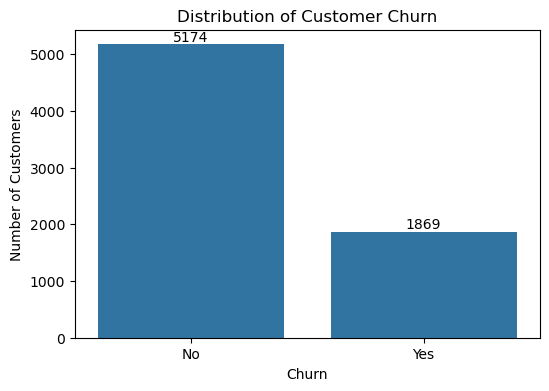

In [8]:
# Target variable distribution
churn_counts = df["Churn"].value_counts()

print("Target Variable Distribution:")
print(churn_counts)

print("\nPercentage Distribution:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# Visualization
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Churn")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 8.2 Distribution of Numerical Features

Understanding the distribution of numerical features helps identify their range, central tendency, skewness, and potential anomalies. Histograms are useful for visualizing how the values are distributed across each numerical feature before applying any preprocessing techniques.

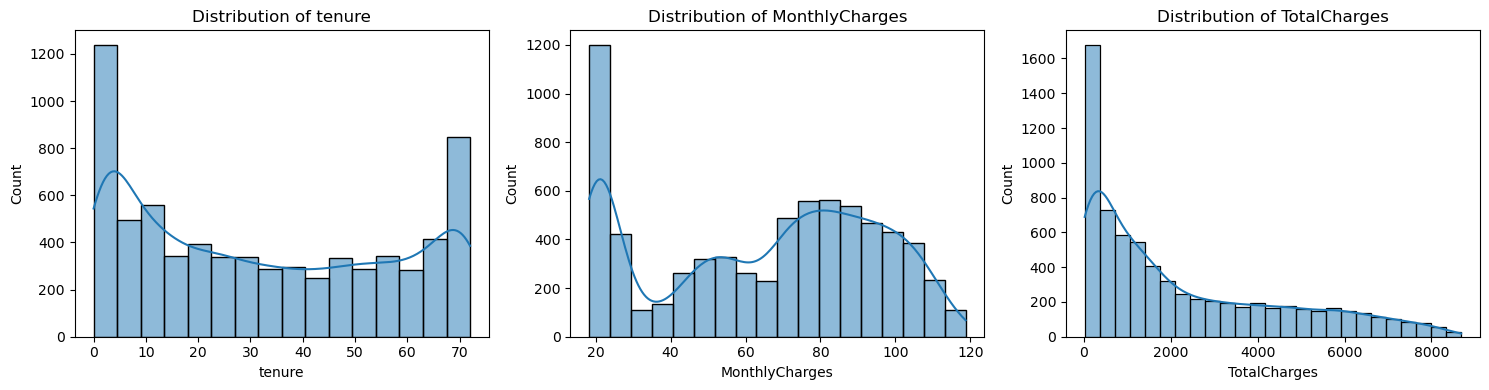

In [9]:
# Exclude SeniorCitizen temporarily
plot_features = [f for f in numerical_features if f != "SeniorCitizen"]

fig, axes = plt.subplots(1, len(plot_features), figsize=(15, 4))

for ax, feature in zip(axes, plot_features):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

### Observations

- **SeniorCitizen:** This is a binary feature with most customers belonging to the non-senior citizen category (0). so hisplot for it.

- **Tenure:** The distribution indicates that many customers are either relatively new or have remained with the company for a long time. This suggests that customer retention varies considerably across different stages of the customer lifecycle.

- **MonthlyCharges:** The distribution appears multimodal, indicating the presence of multiple pricing plans or service packages offered by the telecom company.

- **TotalCharges:** The distribution is positively (right) skewed. Most customers have relatively low total charges, while a smaller number of long-term customers have accumulated much higher charges over time.

## 8.3 Outlier Analysis

Outlier analysis helps identify unusually high or low observations in numerical features. Detecting outliers is important because they can influence certain machine learning algorithms, particularly distance-based and linear models.

In this project, boxplots are used to visualize the distribution of continuous numerical features and identify potential outliers. Since the values in this dataset represent real customer behavior, outliers will be carefully evaluated rather than removed automatically.

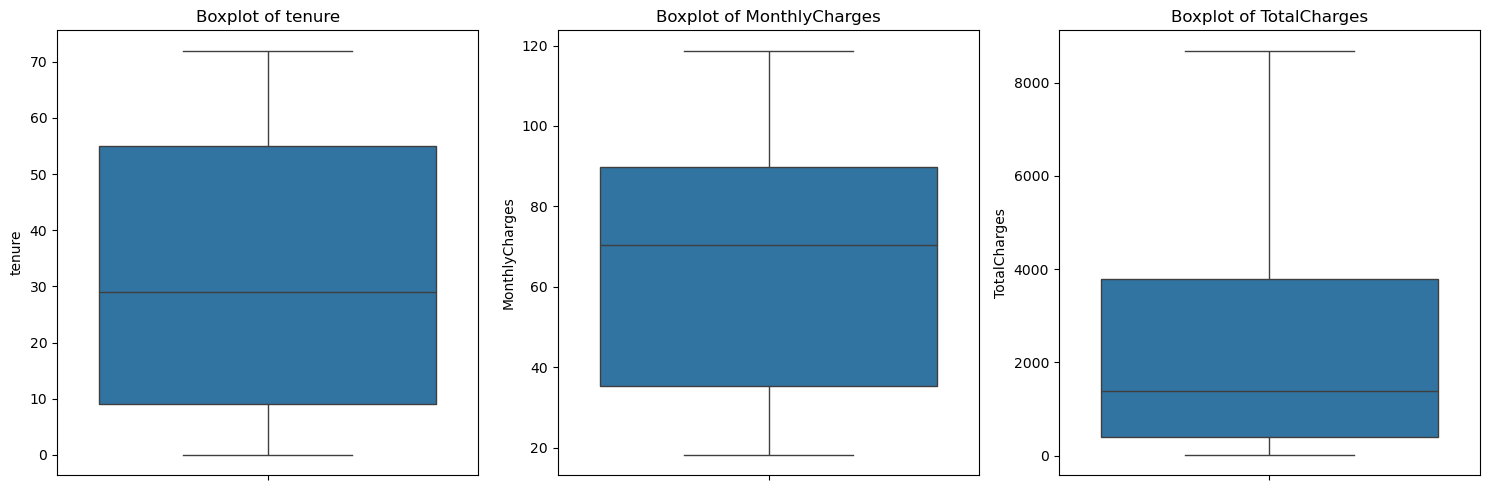

In [10]:
# Continuous numerical features
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, continuous_features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

### Observations

- **Tenure:** The distribution does not exhibit any significant outliers. Customer tenure values are spread across the entire range from 0 to 72 months.

- **MonthlyCharges:** No substantial outliers are observed. The monthly charges are distributed within a reasonable range, suggesting consistent pricing plans across customers.

- **TotalCharges:** Despite being positively skewed, the feature does not contain extreme outliers beyond the whiskers of the boxplot. The higher values correspond to long-term customers who have accumulated charges over time.

**Conclusion:** Since no significant outliers are present, no outlier treatment is required. Retaining these observations preserves valuable customer information and ensures the dataset remains representative of real-world customer behavior.

## 8.4 Correlation Analysis

Correlation analysis helps measure the strength and direction of linear relationships between numerical features. A correlation heatmap provides a quick overview of how numerical variables are related to one another and can help identify potential multicollinearity before model training.

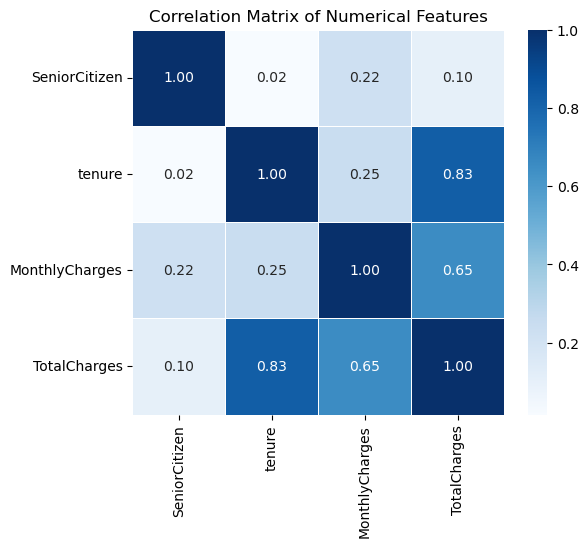

In [11]:
# Correlation matrix for numerical features
plt.figure(figsize=(6,5))

corr = df[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Observations

- **Tenure** and **TotalCharges** exhibit a strong positive correlation (**0.83**). This relationship is expected because customers with longer service durations naturally accumulate higher total charges over time.

- **MonthlyCharges** shows a moderate positive correlation with **TotalCharges** (**0.65**), indicating that customers with higher monthly bills generally accumulate larger total charges.

- **Tenure** and **MonthlyCharges** have a weak positive correlation (**0.25**), suggesting that monthly charges are not strongly dependent on how long a customer has remained with the company.

- **SeniorCitizen** has very weak correlations with the other numerical features, indicating that senior citizen status is largely independent of tenure and billing characteristics.

**Conclusion:** No severe multicollinearity is observed that would require feature removal. Although **Tenure** and **TotalCharges** are strongly correlated, both features capture different aspects of customer behavior and will be retained for model training.

## 8.5 Relationship Between Categorical Features and Customer Churn

Understanding how categorical features relate to customer churn helps identify important patterns in customer behavior. The following visualizations compare the churn distribution across different categories for key service and contract-related features.

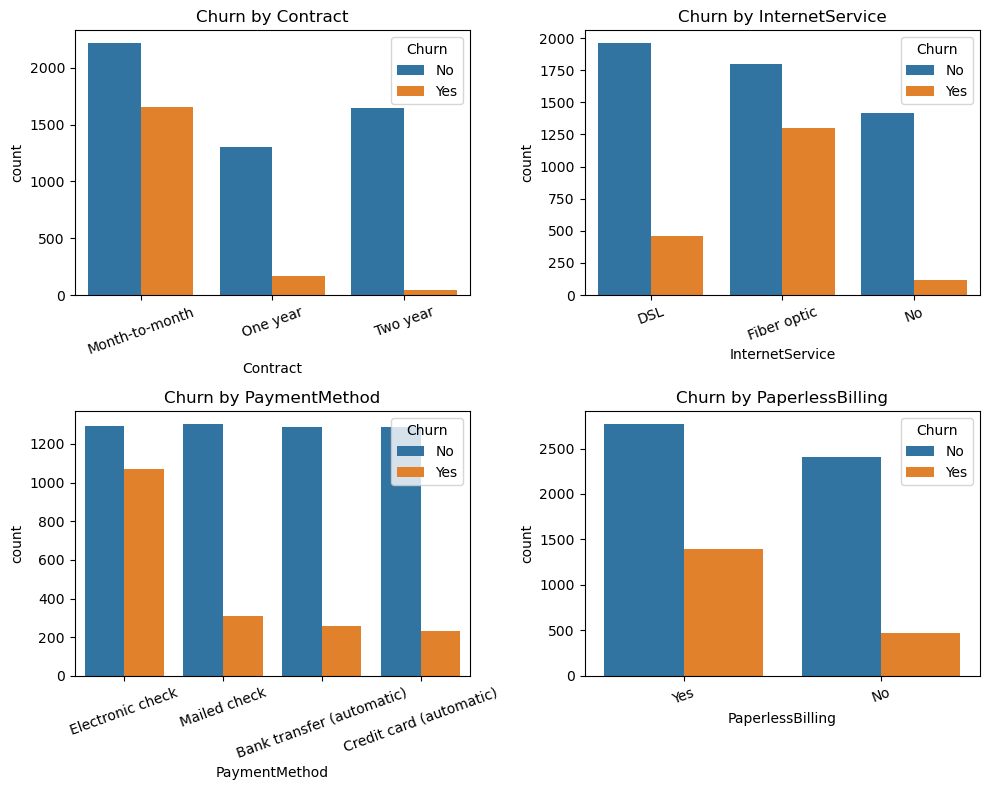

In [12]:
# Key categorical features
key_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), key_features):
    sns.countplot(data=df, x=feature, hue="Churn", ax=ax)
    ax.set_title(f"Churn by {feature}")
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8.6 Relationship Between Numerical Features and Customer Churn

The following boxplots compare the distribution of continuous numerical features for customers who churned and those who remained. This helps identify whether numerical characteristics differ between the two groups.

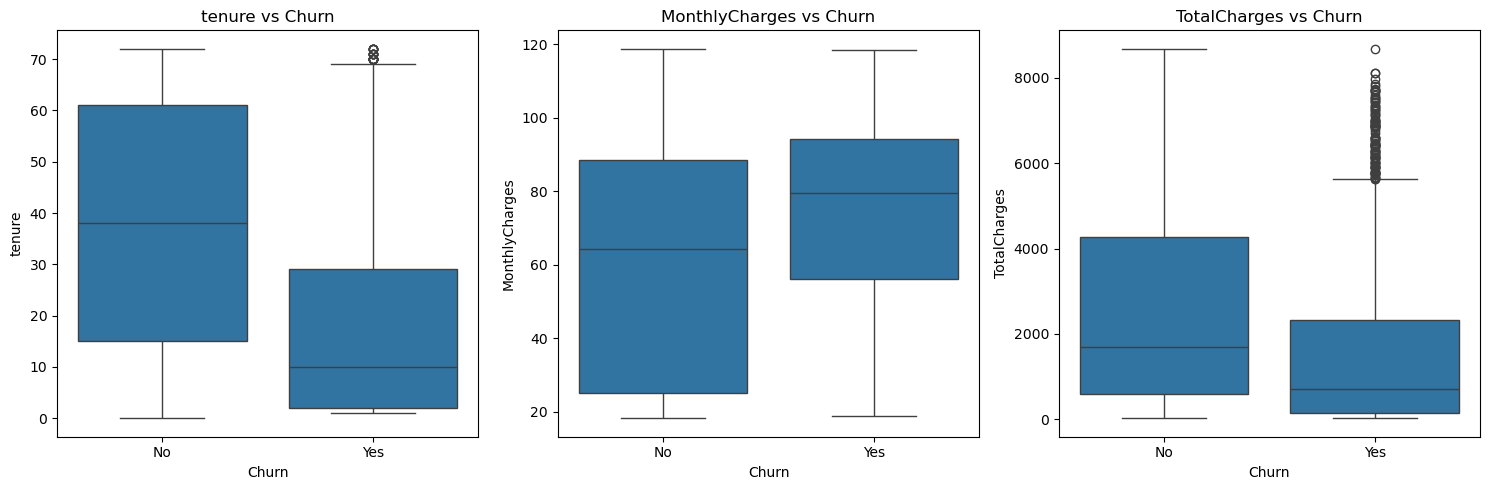

In [13]:
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, feature in zip(axes, continuous_features):
    sns.boxplot(data=df, x="Churn", y=feature, ax=ax)
    ax.set_title(f"{feature} vs Churn")

plt.tight_layout()
plt.show()

### Observations

#### Categorical Features

- **Contract Type:** Customers with **month-to-month contracts** have the highest churn rate, whereas customers with one-year and two-year contracts are much more likely to remain with the company.

- **Internet Service:** Customers using **Fiber Optic** internet exhibit a noticeably higher churn rate compared to DSL users and customers without internet service.

- **Payment Method:** Customers who pay using **Electronic Check** are more likely to churn than those using automatic payment methods.

- **Paperless Billing:** Customers enrolled in **paperless billing** show a higher tendency to churn compared to those receiving paper bills.

#### Numerical Features

- **Tenure:** Customers who churn generally have much shorter tenures, indicating that newer customers are more likely to leave.

- **Monthly Charges:** Customers with higher monthly charges tend to churn more frequently than those with lower monthly charges.

- **Total Charges:** Customers who churn generally have lower total charges because they typically leave the service before accumulating long-term billing.

**Overall Insight:** Contract type, tenure, monthly charges, internet service, and payment method appear to be strong predictors of customer churn and are expected to play an important role in the predictive models.

# 9. Data Preparation

Before training machine learning models, the dataset is prepared by separating the input features and target variable. The target labels are encoded into numerical values, and the data is split into training and testing sets. This ensures that model performance is evaluated on unseen data, providing a reliable estimate of its generalization capability.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (5634, 19)
Testing set : (1409, 19)


# 10. Building the Preprocessing Pipeline

Machine learning models require numerical input features. Since the dataset contains both numerical and categorical variables, different preprocessing techniques are applied to each type.

- **Numerical features** are standardized using `StandardScaler`.
- **Categorical features** are transformed using `OneHotEncoder`.
- These preprocessing steps are combined using a `ColumnTransformer`, creating a reusable and production-ready preprocessing pipeline that can be integrated directly with machine learning models.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


# 11. Logistic Regression Pipeline

Instead of preprocessing the data separately, the preprocessing pipeline is integrated directly with the Logistic Regression model. This ensures that every time the model is trained or used for prediction, the same preprocessing steps are applied automatically, reducing the risk of data leakage and improving reproducibility.

In [16]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

# Train
lr_pipeline.fit(X_train, y_train)

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


# 12. Logistic Regression Model Evaluation

The trained Logistic Regression model is evaluated on the test dataset using multiple classification metrics. Since the target classes are moderately imbalanced, evaluation is not based solely on accuracy. Additional metrics such as precision, recall, F1-score, ROC-AUC score, and the confusion matrix provide a more comprehensive assessment of model performance.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Predictions
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.6040
ROC-AUC  : 0.8419

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrix

A confusion matrix summarizes the classification results by comparing actual and predicted class labels. It provides insights into correctly classified instances as well as false positives and false negatives, helping evaluate the strengths and weaknesses of the model.

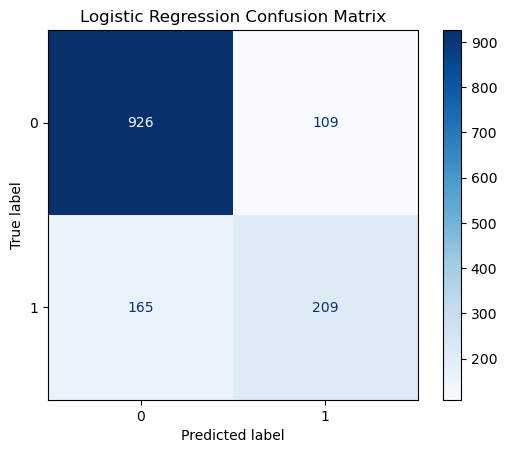

In [18]:
import matplotlib.pyplot as plt

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 13. Random Forest Classification

A Random Forest classifier is trained using the same preprocessing pipeline. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Unlike Logistic Regression, it can capture complex non-linear relationships within the data.

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_estimators=100
        ))
    ]
)

# Train the model
rf_pipeline.fit(X_train, y_train)

print("Random Forest pipeline trained successfully.")

Random Forest pipeline trained successfully.


# 14. Random Forest Model Evaluation

The trained Random Forest model is evaluated using the same performance metrics as Logistic Regression. This allows for a fair comparison between the two models and helps determine which algorithm performs better for customer churn prediction.

In [20]:
# Predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7779
Precision: 0.6034
Recall   : 0.4759
F1-Score : 0.5321
ROC-AUC  : 0.8164

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



## Random Forest Confusion Matrix

The confusion matrix provides a visual summary of the Random Forest model's predictions, showing the number of correctly and incorrectly classified customers for each churn class.

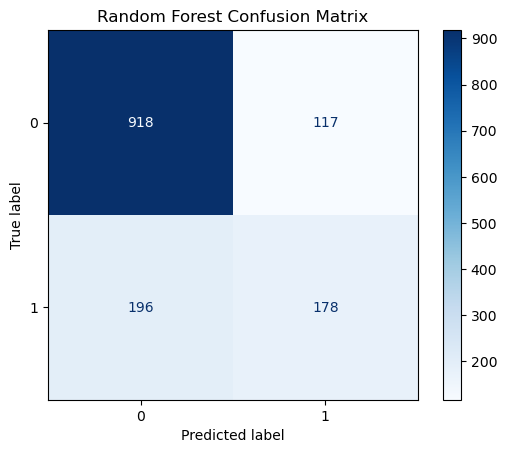

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# 15. Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is performed using **GridSearchCV** to identify the optimal combination of parameters for the Random Forest classifier. Cross-validation is used during the search to ensure that the selected model generalizes well to unseen data.

The best-performing model is selected based on the F1-score, which is particularly suitable for moderately imbalanced classification problems such as customer churn prediction.

In [22]:
from sklearn.model_selection import GridSearchCV

# Random Forest Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

# Hyperparameter grid
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.5786


# 16. Evaluating the Best Random Forest Model

The optimized Random Forest model obtained from GridSearchCV is evaluated on the test dataset. Its performance is compared with the baseline models to determine whether hyperparameter tuning improves predictive performance.

In [23]:
# Best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.8048
Precision: 0.6678
Recall   : 0.5267
F1-Score : 0.5889
ROC-AUC  : 0.8412

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



# 17. Model Comparison

To determine the most suitable model for customer churn prediction, the performance of Logistic Regression, Random Forest, and the tuned Random Forest model is compared using key evaluation metrics. This comparison helps identify the model that provides the best balance between predictive accuracy and generalization performance.

In [24]:
# Create a comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_best)
    ]
})

comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
1,Tuned Random Forest,0.804826,0.667797,0.526738,0.588939,0.841229
2,Random Forest,0.777857,0.603390,0.475936,0.532138,0.816366


# 18. Exporting the Best Model

To ensure reusability and simplify future deployment, the best-performing machine learning pipeline is exported using the `joblib` library. Saving the complete pipeline preserves both the preprocessing steps and the trained model, allowing new data to be processed and predicted without repeating the training process.

In [25]:
import joblib

# Since Logistic Regression achieved the best test performance,
# it is selected as the final production model.
best_pipeline = lr_pipeline

# Save the complete pipeline
joblib.dump(best_pipeline, "customer_churn_pipeline.pkl")

print("Pipeline saved successfully as 'customer_churn_pipeline.pkl'")

Pipeline saved successfully as 'customer_churn_pipeline.pkl'


# 19. Conclusion

This project developed an end-to-end machine learning pipeline for predicting customer churn using the Telco Customer Churn dataset. Data preprocessing was automated using Scikit-learn's `Pipeline` and `ColumnTransformer`, enabling a reusable and production-ready workflow.

Three models were evaluated: Logistic Regression, Random Forest, and a hyperparameter-tuned Random Forest. Although GridSearchCV improved the performance of the Random Forest model, Logistic Regression achieved the highest overall performance on the test dataset.

### Key Findings

- The dataset required preprocessing, including conversion of the `TotalCharges` feature to a numeric data type.
- Contract type, tenure, monthly charges, and internet service showed strong relationships with customer churn.
- Logistic Regression achieved the best overall performance with an accuracy of approximately **80.6%** and an F1-score of **0.604**.
- The complete machine learning pipeline was successfully exported using `joblib`, making it suitable for deployment and future predictions.

Overall, this project demonstrates a production-ready machine learning workflow, including data preprocessing, model training, hyperparameter tuning, evaluation, and model serialization.